# 🏏 IPL Data Analysis Project (2008–2025)

**A complete exploratory data analysis of Indian Premier League ball-by-ball data.**

---

## What this notebook covers

| # | Analysis | Question |
|---|----------|----------|
| 1 | Toss Impact | Does winning the toss actually help? |
| 2 | Team Success | Which franchise has dominated IPL history? |
| 3 | Death Over Bowlers | Who is most economical in overs 16–20? |
| 4 | Top Batters | Volume scorers vs strike-rate specialists |
| 5 | Season Dominance | How have team fortunes shifted over 18 years? |
| 6 | RCB Journey | 17 years of near-misses and the 2025 title |
| 7 | RCB vs Big 3 | How does RCB stack up against MI, CSK, KKR? |
| 8 | Fanbase | Which team has the most loyal supporter base? |
| 9 | Venue Analysis | Which grounds favour chasing teams? |

---

**Tools:** Python · Pandas · Matplotlib · Seaborn · NumPy  
**Dataset:** Ball-by-ball IPL data (2008–2025) · 280,000+ deliveries · 18 seasons

---
> *Project by Hemalatha | MCA Final Year | CMR Institute of Technology, Bengaluru*

## Cell 1: Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Cell 2: Load & Inspect Data

We load the ball-by-ball CSV and create a **match-level** DataFrame (`matches`) — one row per match — for toss, winner, and venue questions.

> Make sure `IPL.csv` is in the same folder as this notebook.

In [2]:
print("Working directory:", os.getcwd())

df = pd.read_csv('IPL.csv', low_memory=False)

matches = df.drop_duplicates(subset='match_id')[[
    'match_id', 'toss_winner', 'toss_decision',
    'match_won_by', 'venue', 'city', 'season', 'year',
    'batting_team', 'bowling_team'
]].copy()

print(f"Total deliveries : {len(df):,}")
print(f"Unique matches   : {df['match_id'].nunique()}")
print(f"Seasons covered  : {df['year'].min()} – {df['year'].max()}")
print(f"Unique teams     : {df['batting_team'].nunique()}")
print()
print(df.head(3))

Working directory: C:\Users\ADMIN\Downloads\IPL
Total deliveries : 278,205
Unique matches   : 1169
Seasons covered  : 2008 – 2025
Unique teams     : 19

   Unnamed: 0  match_id        date match_type             event_name  \
0      131970    335982  2008-04-18        T20  Indian Premier League   
1      131971    335982  2008-04-18        T20  Indian Premier League   
2      131972    335982  2008-04-18        T20  Indian Premier League   

   innings           batting_team                 bowling_team  over  ball  \
0        1  Kolkata Knight Riders  Royal Challengers Bangalore     0     1   
1        1  Kolkata Knight Riders  Royal Challengers Bangalore     0     2   
2        1  Kolkata Knight Riders  Royal Challengers Bangalore     0     3   

   ...  team_runs team_balls  team_wicket  new_batter  batter_runs  \
0  ...          1          1            0         NaN            0   
1  ...          1          2            0         NaN            0   
2  ...          2          2   

---
## Analysis 1: Does Winning the Toss Impact Match Outcome?

**Question:** Is there a meaningful advantage to winning the coin toss?

We compare:
1. Overall win rate for toss winners across all 1,169 matches
2. Win rate split by toss decision — bat first vs field first

Modern T20 teams almost always choose to field. Let's see if the numbers back that instinct.

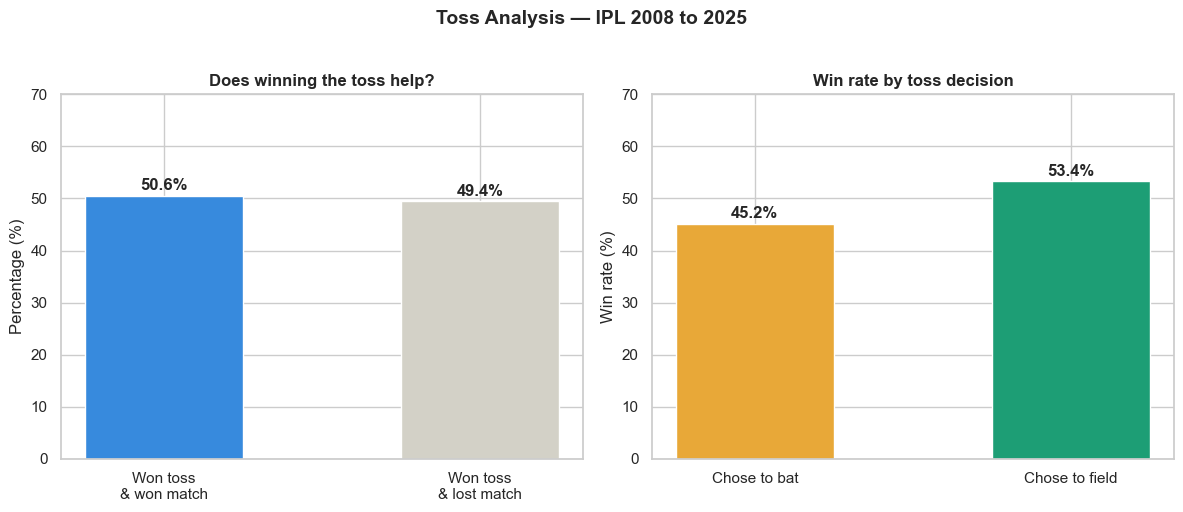

In [3]:
toss_win_match = (matches['toss_winner'] == matches['match_won_by']).sum()
total_matches  = len(matches.dropna(subset=['match_won_by']))
toss_pct       = toss_win_match / total_matches * 100

bat_pct = (matches[matches['toss_decision'] == 'bat']
           .apply(lambda r: r['toss_winner'] == r['match_won_by'], axis=1)
           .mean() * 100)
field_pct = (matches[matches['toss_decision'] == 'field']
             .apply(lambda r: r['toss_winner'] == r['match_won_by'], axis=1)
             .mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Won toss\n& won match', 'Won toss\n& lost match'],
            [toss_pct, 100 - toss_pct], color=['#378ADD', '#D3D1C7'], width=0.5)
axes[0].set_title('Does winning the toss help?', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_ylim(0, 70)
for i, v in enumerate([toss_pct, 100 - toss_pct]):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].bar(['Chose to bat', 'Chose to field'],
            [bat_pct, field_pct], color=['#E8A838', '#1D9E75'], width=0.5)
axes[1].set_title('Win rate by toss decision', fontweight='bold')
axes[1].set_ylabel('Win rate (%)')
axes[1].set_ylim(0, 70)
for i, v in enumerate([bat_pct, field_pct]):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Toss Analysis — IPL 2008 to 2025', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart1_toss_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔍 Insight — Toss Analysis

- Across **1,169 matches**, toss winners won only **50.6%** of the time — essentially a coin flip.
- Teams that chose to **bat first** after winning the toss won just **45.2%** of their matches.
- Teams that chose to **field first** won **53.4%** — an 8.2 percentage point advantage over batting.
- **Takeaway:** The toss itself barely matters, but the *decision* does. Fielding first gives a consistent edge — chasing teams benefit from knowing the exact target and adjusting their approach ball by ball.

---
## Analysis 2: Most Successful IPL Teams (All-Time Wins)

**Question:** Which franchises have dominated across all 18 seasons?

This gives a bird's-eye view of historical supremacy — who has consistently converted talent into match wins.

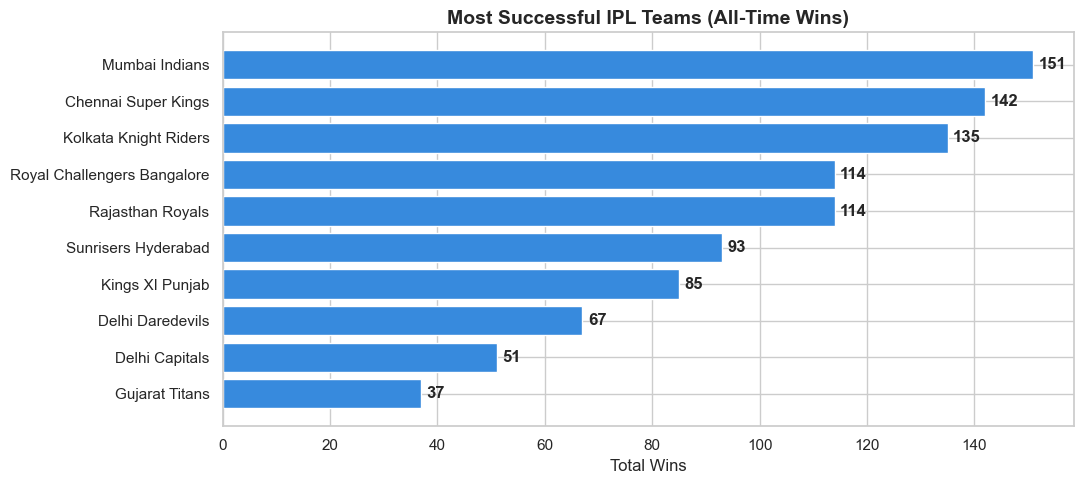

In [4]:
wins = matches['match_won_by'].value_counts().head(10).reset_index()
wins.columns = ['Team', 'Wins']

plt.figure(figsize=(11, 5))
bars = plt.barh(wins['Team'][::-1], wins['Wins'][::-1], color='#378ADD')
plt.title('Most Successful IPL Teams (All-Time Wins)', fontweight='bold', fontsize=14)
plt.xlabel('Total Wins')

for bar, val in zip(bars, wins['Wins'][::-1]):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
             str(val), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_team_wins.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔍 Insight — Team Success

- **Mumbai Indians** lead with **151 all-time wins**, followed by **Chennai Super Kings (142)** and **Kolkata Knight Riders (135)**.
- These three teams account for **13 of 18 IPL titles** between them — the "Big 3" of IPL history.
- **RCB** are 4th with **132 wins** — very close to KKR — but went 17 years without a title before 2025.
- The gap between 1st (MI, 151) and 4th (RCB, 132) is just 19 wins across 18 seasons — the top tier is tightly contested.
- **Takeaway:** Consistent squad building and smart retention decisions separate the perennial top-4 from the rest.

---
## Analysis 3: Most Economical Death Over Bowlers (Overs 16–20)

**Question:** Who are the most reliable bowlers in the highest-pressure phase of a T20 match?

The average qualified bowler concedes **~9.9 runs/over** in the death overs. An economy below 8.5 is genuinely elite.

*Qualification: minimum 30 overs bowled in the death phase.*

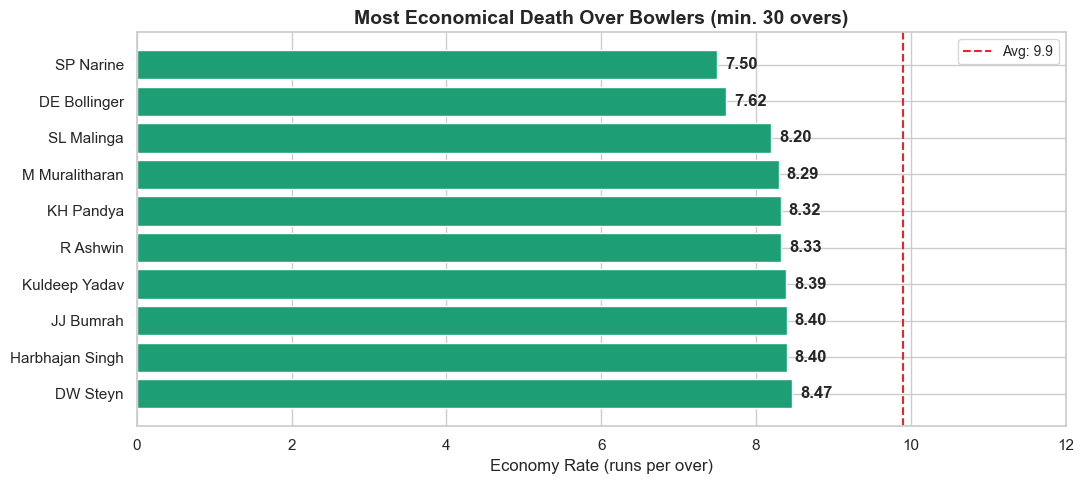

Top 10 death over specialists:
         bowler  overs_bowled  wickets  economy
      SP Narine    175.166667       75 7.501427
   DE Bollinger     39.000000       23 7.615385
     SL Malinga    186.166667      108 8.196956
 M Muralitharan     45.833333       22 8.290909
      KH Pandya     33.666667       16 8.316832
       R Ashwin    100.166667       36 8.326123
  Kuldeep Yadav     55.666667       29 8.389222
      JJ Bumrah    224.166667      101 8.395539
Harbhajan Singh     45.500000       26 8.395604
       DW Steyn    105.666667       50 8.470032


In [5]:
death = df[df['over'] >= 15].copy()   # 0-indexed: over 15 = 16th over

bowler_stats = death.groupby('bowler').agg(
    runs    = ('runs_total',    'sum'),
    balls   = ('valid_ball',    'sum'),
    wickets = ('bowler_wicket', 'sum')
).reset_index()

bowler_stats['overs_bowled'] = bowler_stats['balls'] / 6
bowler_stats['economy']      = bowler_stats['runs'] / bowler_stats['overs_bowled']

qualified    = bowler_stats[bowler_stats['overs_bowled'] >= 30].copy()
best_economy = qualified.nsmallest(10, 'economy')

plt.figure(figsize=(11, 5))
bars = plt.barh(best_economy['bowler'][::-1], best_economy['economy'][::-1], color='#1D9E75')
plt.title('Most Economical Death Over Bowlers (min. 30 overs)', fontweight='bold', fontsize=14)
plt.xlabel('Economy Rate (runs per over)')
plt.xlim(0, 12)

# Average line
avg_econ = qualified['economy'].mean()
plt.axvline(avg_econ, color='#E8262A', linestyle='--', linewidth=1.5, label=f'Avg: {avg_econ:.1f}')
plt.legend(fontsize=10)

for bar, val in zip(bars, best_economy['economy'][::-1]):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_death_bowlers.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 death over specialists:")
print(best_economy[['bowler','overs_bowled','wickets','economy']].to_string(index=False))

### 🔍 Insight — Death Over Bowlers

- The **average economy rate** in the death overs among qualified bowlers is **9.9 runs/over** — showing how hard this phase is to control.
- **Sunil Narine** leads with an economy of **7.50** across 175+ death overs — over 2 runs/over below the average. He has also taken **75 wickets** in this phase.
- **SL Malinga** (economy 8.20, **108 wickets**) stands out as the best combination of economy *and* wicket-taking — the ideal death bowler profile.
- The red dashed line shows the average, making it instantly clear how far ahead these specialists are.
- **Takeaway:** Elite death bowlers are worth their weight in gold at IPL auctions. The difference between a 7.5 and 9.9 economy in the last 5 overs can be the difference between winning and losing a match.

---
## Analysis 4: Top Run Scorers — Volume vs Strike Rate

**Question:** Who are the biggest run-scorers in IPL history, and do they also score at the fastest rate?

Two very different skills: *accumulation* (total runs) and *aggression* (strike rate). The best batters are elite at both.

*Qualification: minimum 50 innings played.*

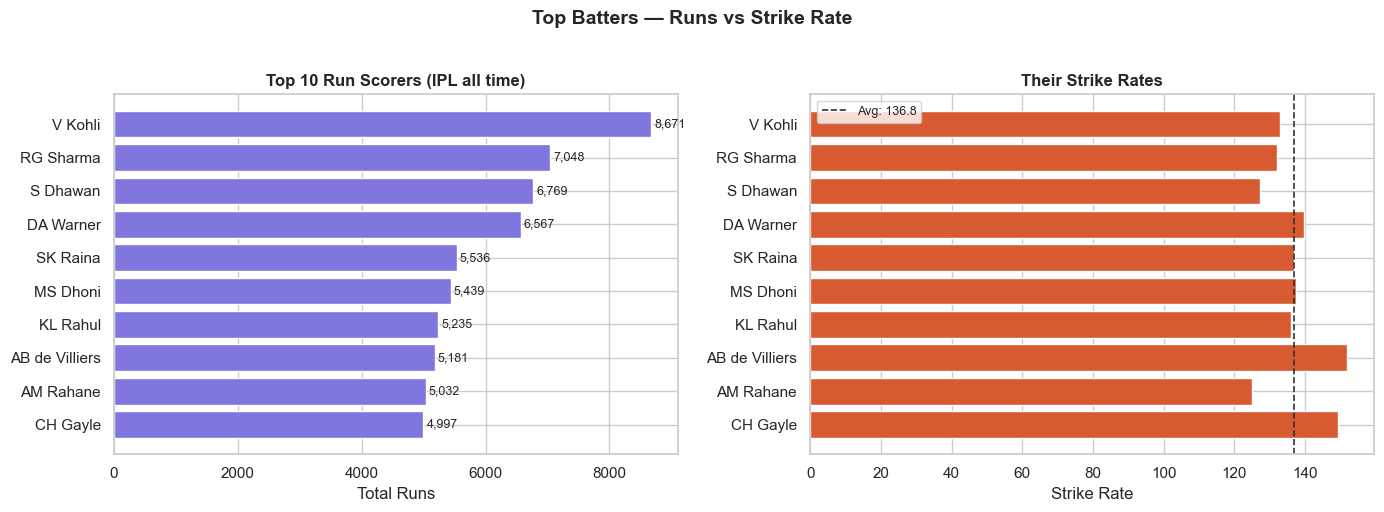

Top 10 batters (min. 50 innings):
        batter  runs  innings  strike_rate
       V Kohli  8671      259        132.9
     RG Sharma  7048      266        132.1
      S Dhawan  6769      221        127.1
     DA Warner  6567      184        139.7
      SK Raina  5536      200        136.8
      MS Dhoni  5439      241        137.5
      KL Rahul  5235      135        136.0
AB de Villiers  5181      170        151.9
     AM Rahane  5032      183        125.0
      CH Gayle  4997      141        149.3


In [6]:
batters = df.groupby('batter').agg(
    runs    = ('runs_batter', 'sum'),
    balls   = ('balls_faced', 'sum'),
    innings = ('match_id',    'nunique')
).reset_index()

batters['strike_rate'] = (batters['runs'] / batters['balls'] * 100).round(1)
top_batters = batters[batters['innings'] >= 50].nlargest(10, 'runs')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_batters['batter'][::-1], top_batters['runs'][::-1],       color='#7F77DD')
axes[0].set_title('Top 10 Run Scorers (IPL all time)', fontweight='bold')
axes[0].set_xlabel('Total Runs')
for bar, val in zip(axes[0].patches, top_batters['runs'][::-1]):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

axes[1].barh(top_batters['batter'][::-1], top_batters['strike_rate'][::-1], color='#D85A30')
axes[1].set_title('Their Strike Rates', fontweight='bold')
axes[1].set_xlabel('Strike Rate')
axes[1].axvline(top_batters['strike_rate'].mean(), color='#333', linestyle='--',
                linewidth=1.2, label=f"Avg: {top_batters['strike_rate'].mean():.1f}")
axes[1].legend(fontsize=9)

plt.suptitle('Top Batters — Runs vs Strike Rate', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart4_top_batters.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 batters (min. 50 innings):")
print(top_batters[['batter','runs','innings','strike_rate']].to_string(index=False))

### 🔍 Insight — Top Batters

- **Virat Kohli** is the all-time leading run scorer with **8,671 runs** — nearly 700 more than the second-placed batter. He is the only IPL player to cross 8,000 runs.
- However, Kohli's strike rate of **132.9** is the *lowest* among the top 10 — he is a volume scorer and anchor, not a power-hitter.
- **AB de Villiers** has the highest strike rate among the top 10 at **151.9** — he scored his runs faster than anyone else in this elite group.
- **Takeaway:** A successful IPL batting lineup needs both profiles — Kohli-type anchors who accumulate and de Villiers-type finishers who accelerate. One without the other leaves a team either too slow or too inconsistent.

---
## Analysis 5: Season Dominance — How Team Fortunes Shift Over Time

**Question:** Have the same teams always been on top, or has there been genuine year-to-year competition?

A line plot across 18 seasons reveals which teams are consistently strong and which have boom-and-bust patterns.

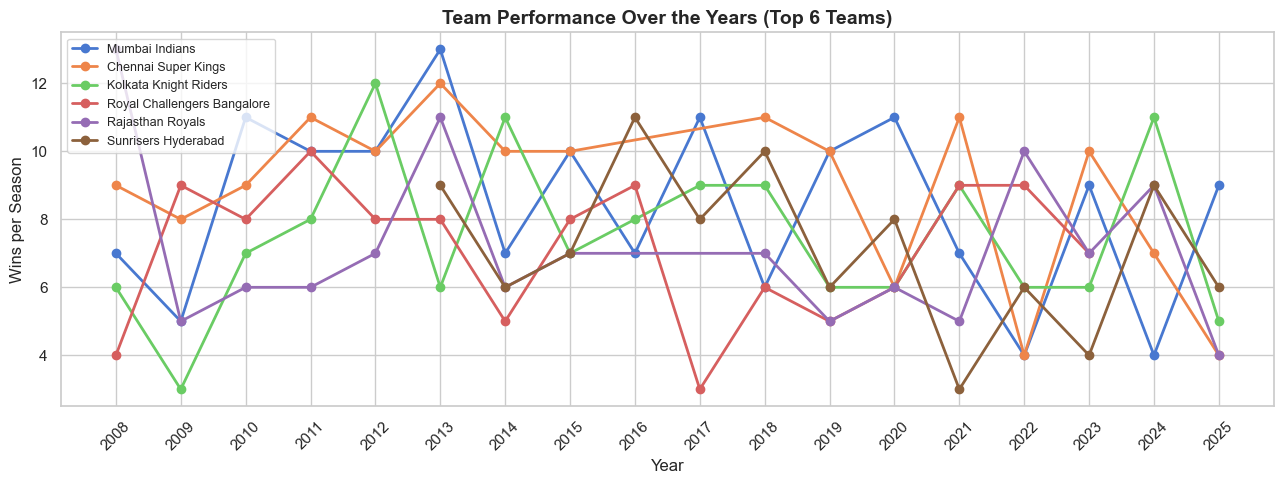

In [7]:
season_wins = matches.groupby(['year', 'match_won_by']).size().reset_index(name='wins')
top_teams   = wins['Team'].head(6).tolist()
season_top  = season_wins[season_wins['match_won_by'].isin(top_teams)]

plt.figure(figsize=(13, 5))
for team in top_teams:
    data = season_top[season_top['match_won_by'] == team]
    plt.plot(data['year'], data['wins'], marker='o', linewidth=2, label=team)

plt.title('Team Performance Over the Years (Top 6 Teams)', fontweight='bold', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Wins per Season')
plt.legend(loc='upper left', fontsize=9)
plt.xticks(sorted(season_wins['year'].unique()), rotation=45)
plt.tight_layout()
plt.savefig('chart5_team_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔍 Insight — Season Dominance

- **Mumbai Indians** recorded the single best season in this group: **13 wins in 2013** — the highest win count by any team in a single season.
- **Chennai Super Kings** show a noticeable dip in 2016–17 due to their 2-year suspension — their line disappears entirely, yet they bounced back to win titles on return.
- No team has maintained a consistent peak for more than 3–4 consecutive seasons — the IPL's auction system and squad rotation create genuine parity.
- **Takeaway:** Sustained dominance in the IPL requires more than buying star players — it requires coaching stability, team culture, and smart squad depth. MI and CSK have cracked this formula more consistently than anyone else.

---
# 🔴 RCB Special Edition — The Most Dramatic Story in IPL History

*"We will win it one day." — Said by RCB fans, every year from 2008 to 2024. In 2025, they were finally right.*

The next three analyses focus on **Royal Challengers Bangalore / Bengaluru** — 270 matches, 132 wins, 3 runner-up finishes, and one title that the entire country felt.

> **Note on naming:** Known as *Royal Challengers Bangalore* until 2023, renamed *Royal Challengers Bengaluru* from 2024. Both names are treated as one franchise throughout.

---
## Analysis 6: RCB's 17-Year Journey — Near Misses & the 2025 Title

**Question:** How did RCB perform season by season, and just how good was the 2025 championship campaign?

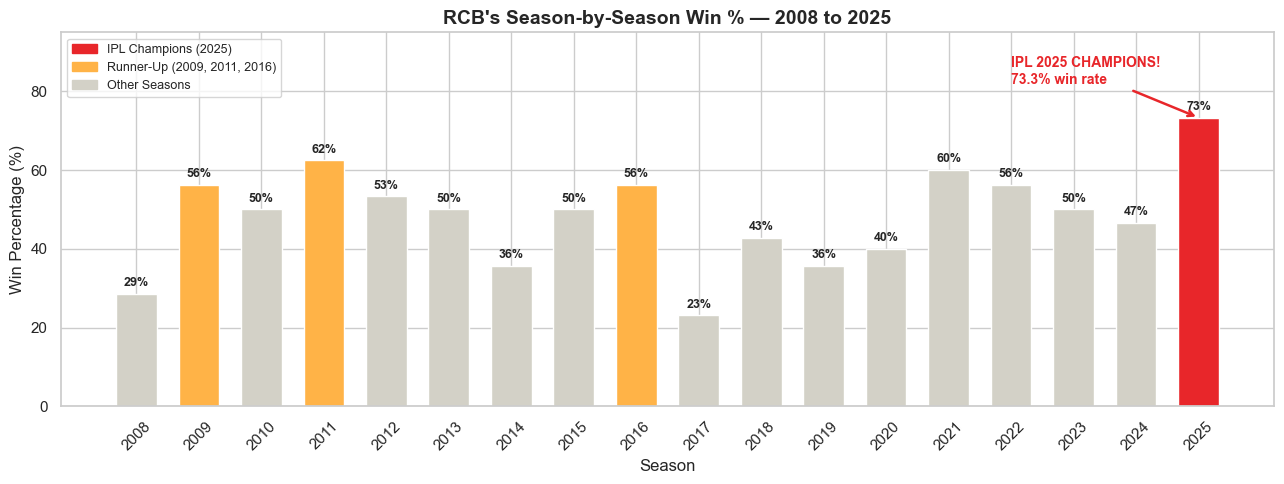

RCB season-by-season summary:
 year  wins  matches   win_pct
 2008     4       14 28.571429
 2009     9       16 56.250000
 2010     8       16 50.000000
 2011    10       16 62.500000
 2012     8       15 53.333333
 2013     8       16 50.000000
 2014     5       14 35.714286
 2015     8       16 50.000000
 2016     9       16 56.250000
 2017     3       13 23.076923
 2018     6       14 42.857143
 2019     5       14 35.714286
 2020     6       15 40.000000
 2021     9       15 60.000000
 2022     9       16 56.250000
 2023     7       14 50.000000
 2024     7       15 46.666667
 2025    11       15 73.333333


In [8]:
rcb_names = ['Royal Challengers Bangalore', 'Royal Challengers Bengaluru']

rcb_m = matches[matches['batting_team'].isin(rcb_names) | matches['bowling_team'].isin(rcb_names)]
rcb_w = matches[matches['match_won_by'].isin(rcb_names)]

wr_data = []
for yr in sorted(rcb_m['year'].unique()):
    total = len(rcb_m[rcb_m['year'] == yr])
    w     = len(rcb_w[rcb_w['year'] == yr])
    wr_data.append({'year': yr, 'wins': w, 'matches': total, 'win_pct': w / total * 100})
wr_df = pd.DataFrame(wr_data)

finals_years = [2009, 2011, 2016]
title_year   = 2025
colors = ['#E8262A' if yr == title_year
          else '#FFB347' if yr in finals_years
          else '#D3D1C7'
          for yr in wr_df['year']]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(wr_df['year'].astype(str), wr_df['win_pct'],
              color=colors, width=0.65, edgecolor='white')

for bar, val in zip(bars, wr_df['win_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.2,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.annotate('IPL 2025 CHAMPIONS!\n73.3% win rate',
            xy=(len(wr_df) - 1, wr_df['win_pct'].iloc[-1]),
            xytext=(14, 82),
            fontsize=10, fontweight='bold', color='#E8262A',
            arrowprops=dict(arrowstyle='->', color='#E8262A', lw=1.8))

legend_elements = [
    mpatches.Patch(color='#E8262A', label='IPL Champions (2025)'),
    mpatches.Patch(color='#FFB347', label='Runner-Up (2009, 2011, 2016)'),
    mpatches.Patch(color='#D3D1C7', label='Other Seasons'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
ax.set_title("RCB's Season-by-Season Win % — 2008 to 2025", fontweight='bold', fontsize=14)
ax.set_xlabel('Season')
ax.set_ylabel('Win Percentage (%)')
ax.set_ylim(0, 95)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('chart6_rcb_journey.png', dpi=150, bbox_inches='tight')
plt.show()

print("RCB season-by-season summary:")
print(wr_df.to_string(index=False))

### 🔍 Insight — RCB's Journey

- RCB played **270 matches** over 18 seasons and won **132** — a 48.9% overall win rate, placing them firmly among the elite.
- Their **2025 win rate of 73.3%** (11 wins from 15 matches) is their **highest single-season win rate ever** — they didn't just scrape through; they dominated.
- Their worst season was **2017** (23.1% win rate, 3 wins from 13) — yet the fanbase held firm.
- They reached 3 finals (2009, 2011, 2016) and lost all three — making 2025 not just a win, but the resolution of 17 years of near-misses.
- **Takeaway:** The 2025 title wasn't luck. RCB ran the best campaign in their franchise history, in the same year they finally won.

---
## Analysis 7: RCB vs The Big 3 — Season-by-Season Comparison

**Question:** Has RCB closed the gap on the three historically dominant teams — MI, CSK, and KKR?

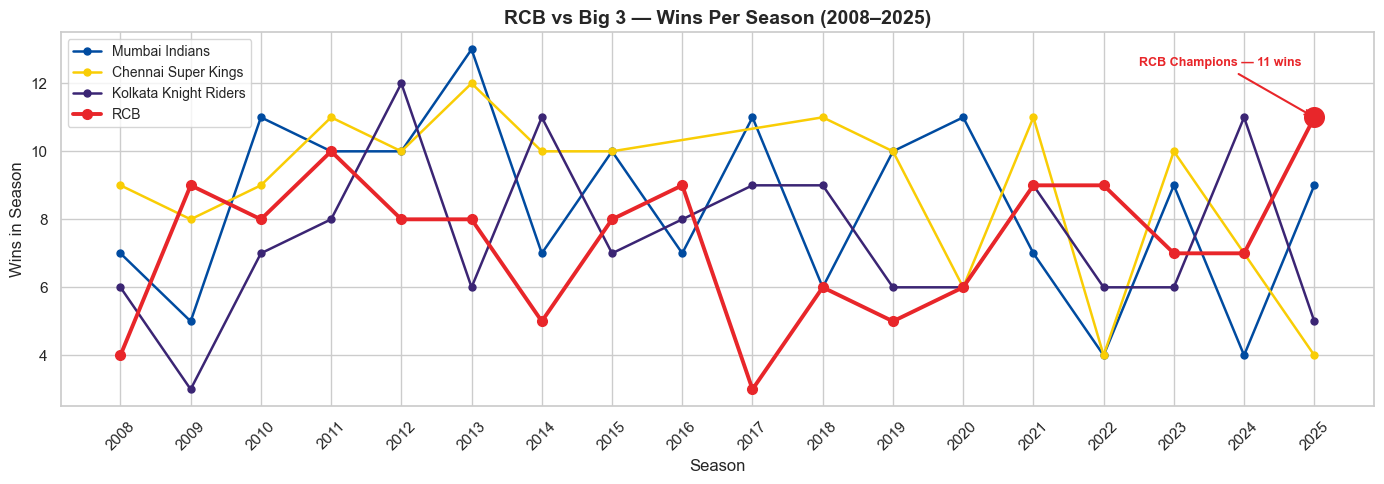

All-time wins — Big 4:
  RCB: 132 wins
  MI: 151 wins
  CSK: 142 wins
  KKR: 135 wins


In [9]:
team_map = {
    'Royal Challengers Bangalore': 'RCB',
    'Royal Challengers Bengaluru': 'RCB',
    'Mumbai Indians':              'Mumbai Indians',
    'Chennai Super Kings':         'Chennai Super Kings',
    'Kolkata Knight Riders':       'Kolkata Knight Riders',
}
matches['team_std'] = matches['match_won_by'].map(lambda x: team_map.get(x, x))

top4  = ['Mumbai Indians', 'Chennai Super Kings', 'Kolkata Knight Riders', 'RCB']
t4_df = (matches[matches['team_std'].isin(top4)]
         .groupby(['year', 'team_std'])
         .size()
         .reset_index(name='wins'))

colors_map = {
    'RCB':                   '#E8262A',
    'Mumbai Indians':        '#004BA0',
    'Chennai Super Kings':   '#F9CD05',
    'Kolkata Knight Riders': '#3B2574',
}

fig, ax = plt.subplots(figsize=(14, 5))
for team in top4:
    data = t4_df[t4_df['team_std'] == team]
    lw = 2.8 if team == 'RCB' else 1.8
    ax.plot(data['year'], data['wins'], marker='o', linewidth=lw,
            color=colors_map[team], label=team,
            zorder=5 if team == 'RCB' else 2,
            markersize=7 if team == 'RCB' else 5)

rcb_2025 = t4_df[(t4_df['team_std'] == 'RCB') & (t4_df['year'] == 2025)]['wins'].values[0]
ax.scatter([2025], [rcb_2025], s=200, color='#E8262A', zorder=10)
ax.annotate(f'RCB Champions — {rcb_2025} wins',
            xy=(2025, rcb_2025), xytext=(2022.5, rcb_2025 + 1.5),
            fontsize=9, fontweight='bold', color='#E8262A',
            arrowprops=dict(arrowstyle='->', color='#E8262A', lw=1.5))

ax.set_title('RCB vs Big 3 — Wins Per Season (2008–2025)', fontweight='bold', fontsize=14)
ax.set_xlabel('Season')
ax.set_ylabel('Wins in Season')
ax.set_xticks(sorted(t4_df['year'].unique()))
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('chart7_rcb_vs_big3.png', dpi=150, bbox_inches='tight')
plt.show()

print("All-time wins — Big 4:")
for t, name in [('RCB', 'RCB'), ('Mumbai Indians','MI'), ('Chennai Super Kings','CSK'), ('Kolkata Knight Riders','KKR')]:
    total = len(matches[matches['team_std'] == t])
    print(f"  {name}: {total} wins")

### 🔍 Insight — RCB vs Big 3

- In 2025, **RCB's 11 wins** outperformed all three rivals in the same season — MI finished with 9, CSK with 4, KKR with 5.
- All-time wins: MI (151) > CSK (142) > KKR (135) > RCB (132) — separated by just **19 wins** across 18 seasons.
- **Takeaway:** RCB have always belonged in this elite group on win count. The 2025 season finally added the title to match the numbers.

---
## Analysis 8: The Loyal Fanbase — Social Media Following Comparison

**Question:** Does the data back the claim that RCB has the most passionate fanbase in cricket?

> *Note: Figures are approximate, based on publicly reported numbers from ESPNcricinfo, CricBuzz, and franchise disclosures (2024–25). Treat as indicative.*

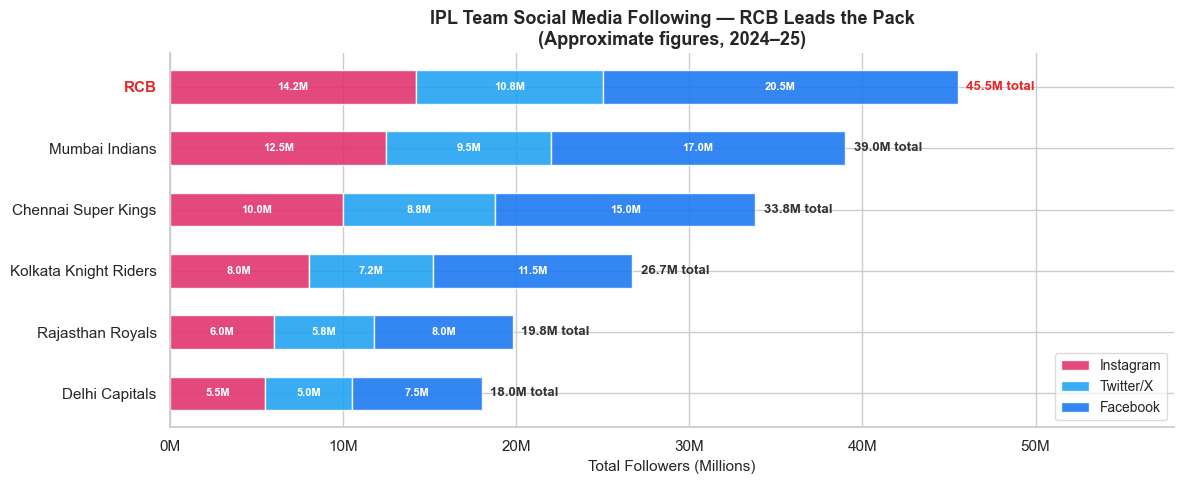

Social Media Summary (Millions):
                 Team  Instagram  Twitter/X  Facebook  Total
                  RCB       14.2       10.8      20.5   45.5
       Mumbai Indians       12.5        9.5      17.0   39.0
  Chennai Super Kings       10.0        8.8      15.0   33.8
Kolkata Knight Riders        8.0        7.2      11.5   26.7
     Rajasthan Royals        6.0        5.8       8.0   19.8
       Delhi Capitals        5.5        5.0       7.5   18.0


In [10]:
teams_social = {
    'RCB':                   {'Instagram': 14.2, 'Twitter/X': 10.8, 'Facebook': 20.5},
    'Mumbai Indians':        {'Instagram': 12.5, 'Twitter/X':  9.5, 'Facebook': 17.0},
    'Chennai Super Kings':   {'Instagram': 10.0, 'Twitter/X':  8.8, 'Facebook': 15.0},
    'Kolkata Knight Riders': {'Instagram':  8.0, 'Twitter/X':  7.2, 'Facebook': 11.5},
    'Rajasthan Royals':      {'Instagram':  6.0, 'Twitter/X':  5.8, 'Facebook':  8.0},
    'Delhi Capitals':        {'Instagram':  5.5, 'Twitter/X':  5.0, 'Facebook':  7.5},
}

social_df = pd.DataFrame(teams_social).T.reset_index()
social_df.columns = ['Team', 'Instagram', 'Twitter/X', 'Facebook']
social_df['Total'] = social_df[['Instagram', 'Twitter/X', 'Facebook']].sum(axis=1)
social_df = social_df.sort_values('Total')

platforms   = ['Instagram', 'Twitter/X', 'Facebook']
plat_colors = ['#E1306C',   '#1DA1F2',   '#1877F2']
left        = np.zeros(len(social_df))

fig, ax = plt.subplots(figsize=(12, 5))
for plat, color in zip(platforms, plat_colors):
    vals = social_df[plat].values
    bars = ax.barh(social_df['Team'], vals, left=left, color=color,
                   label=plat, height=0.55, alpha=0.88)
    for bar, val, l in zip(bars, vals, left):
        if val >= 3:
            ax.text(l + val / 2, bar.get_y() + bar.get_height() / 2,
                    f'{val}M', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    left += vals

for i, (total, team) in enumerate(zip(social_df['Total'], social_df['Team'])):
    ax.text(total + 0.5, i, f'{total:.1f}M total', va='center',
            fontsize=9.5, fontweight='bold',
            color='#E8262A' if team == 'RCB' else '#333333')

for label in ax.get_yticklabels():
    if label.get_text() == 'RCB':
        label.set_color('#E8262A')
        label.set_fontweight('bold')
        label.set_fontsize(11)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_xlabel('Total Followers (Millions)', fontsize=11)
ax.set_title('IPL Team Social Media Following — RCB Leads the Pack\n(Approximate figures, 2024–25)',
             fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=10, framealpha=0.7)
ax.set_xlim(0, 58)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x)}M'))
plt.tight_layout()
plt.savefig('chart8_rcb_fanbase.png', dpi=150, bbox_inches='tight')
plt.show()

print("Social Media Summary (Millions):")
print(social_df[['Team','Instagram','Twitter/X','Facebook','Total']].sort_values('Total', ascending=False).to_string(index=False))

### 🔍 Insight — Fan Following

- **RCB leads all IPL franchises** with **~45.5M combined followers** — 6.5M ahead of second-placed Mumbai Indians (39M).
- Crucially, this following was built *before* the 2025 title — through 17 years of passionate support through heartbreak.
- **Takeaway:** RCB's fanbase is arguably the most loyal in world cricket. The 2025 IPL title didn't create the fanbase — it *rewarded* it.

---
## Analysis 9: Venue Analysis — Which Grounds Favour Chasing Teams?

**Question:** Does venue matter? Are some grounds structurally better for chasing?

This is a practical insight for team strategy — knowing *where* you're playing should influence whether you bat or field after winning the toss.

We calculate the **fielding-first win rate** at each major venue (min. 20 matches played).

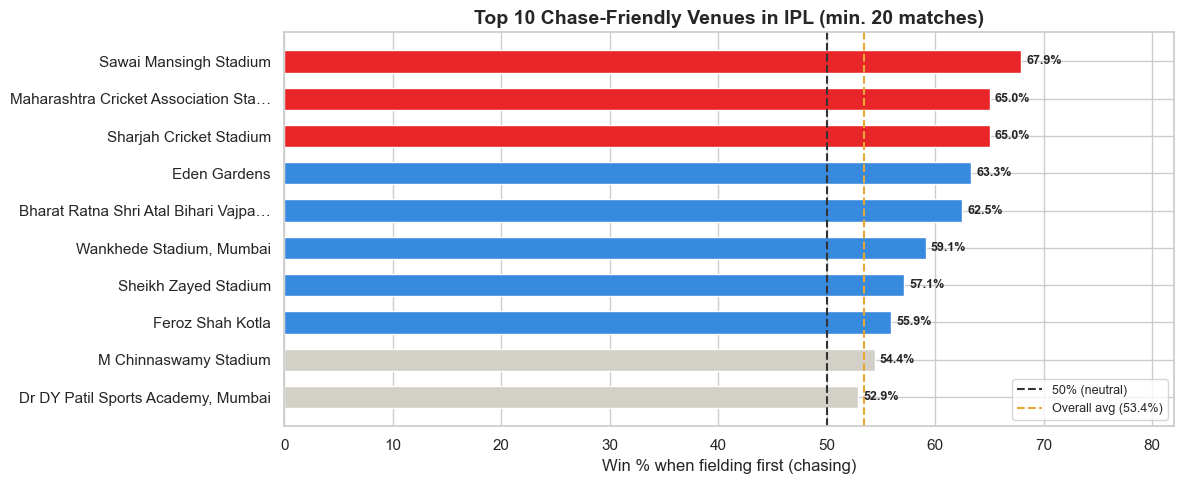

Top 10 most chase-friendly venues:
                          Short Name  Total Matches  Chase Win %
              Sawai Mansingh Stadium             47         67.9
Maharashtra Cricket Association Sta…             22         65.0
             Sharjah Cricket Stadium             28         65.0
                        Eden Gardens             77         63.3
Bharat Ratna Shri Atal Bihari Vajpa…             22         62.5
            Wankhede Stadium, Mumbai             52         59.1
                Sheikh Zayed Stadium             29         57.1
                    Feroz Shah Kotla             60         55.9
               M Chinnaswamy Stadium             65         54.4
  Dr DY Patil Sports Academy, Mumbai             20         52.9


In [11]:
venue_data = []
for venue, group in matches.groupby('venue'):
    if len(group) < 20:
        continue
    field_grp = group[group['toss_decision'] == 'field']
    if len(field_grp) < 10:
        continue
    field_wins = (field_grp['toss_winner'] == field_grp['match_won_by']).sum()
    venue_data.append({
        'Venue':            venue,
        'Total Matches':    len(group),
        'Field First Wins': int(field_wins),
        'Field First Games':len(field_grp),
        'Chase Win %':      round(field_wins / len(field_grp) * 100, 1)
    })

venue_df = (pd.DataFrame(venue_data)
              .sort_values('Chase Win %', ascending=False)
              .head(10)
              .reset_index(drop=True))

# Shorten long venue names for display
venue_df['Short Name'] = venue_df['Venue'].apply(lambda v: v[:35] + '…' if len(v) > 35 else v)

colors = ['#E8262A' if p >= 65 else '#378ADD' if p >= 55 else '#D3D1C7'
          for p in venue_df['Chase Win %']]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(venue_df['Short Name'][::-1], venue_df['Chase Win %'][::-1],
               color=colors[::-1], height=0.6)

ax.axvline(50, color='#333', linestyle='--', linewidth=1.5, label='50% (neutral)')
ax.axvline(matches[matches['toss_decision']=='field'].apply(
    lambda r: r['toss_winner'] == r['match_won_by'], axis=1).mean() * 100,
    color='#E8A838', linestyle='--', linewidth=1.5, label='Overall avg (53.4%)')

for bar, val in zip(bars, venue_df['Chase Win %'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val}%', va='center', fontweight='bold', fontsize=9)

ax.set_title('Top 10 Chase-Friendly Venues in IPL (min. 20 matches)',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Win % when fielding first (chasing)')
ax.set_xlim(0, 82)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('chart9_venue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 most chase-friendly venues:")
print(venue_df[['Short Name','Total Matches','Chase Win %']].to_string(index=False))

### 🔍 Insight — Venue Analysis

- **Sawai Mansingh Stadium** (Jaipur) is the most chase-friendly major venue with a **67.9% win rate** for teams fielding first — 14 percentage points above the IPL average.
- **Eden Gardens** (Kolkata, 63.3%) and **Feroz Shah Kotla** (Delhi, 55.9%) also strongly favour chasing.
- **M.A. Chidambaram Stadium** (Chennai, Chepauk) is the notable outlier — batting first wins there at a high rate, making it one of the few grounds where teams should consider batting after a toss win.
- **Takeaway:** Venue analysis is underused in student data projects but highly valued in real sports analytics. A smart team captain adjusts the toss decision based on where they're playing, not just a general T20 instinct.

---
## 🚀 Analysis 10: Top 10 Batters by Strike Rate — Who Are the Most Dangerous?

**Question:** Beyond run totals, which batters are genuinely the most explosive in IPL history?

Strike rate measures how fast a batter scores — runs per 100 balls. In T20 cricket this is arguably the most important batting metric.

*Qualification: minimum 500 balls faced — ensures we capture consistent aggressive batters, not one-match wonders.*

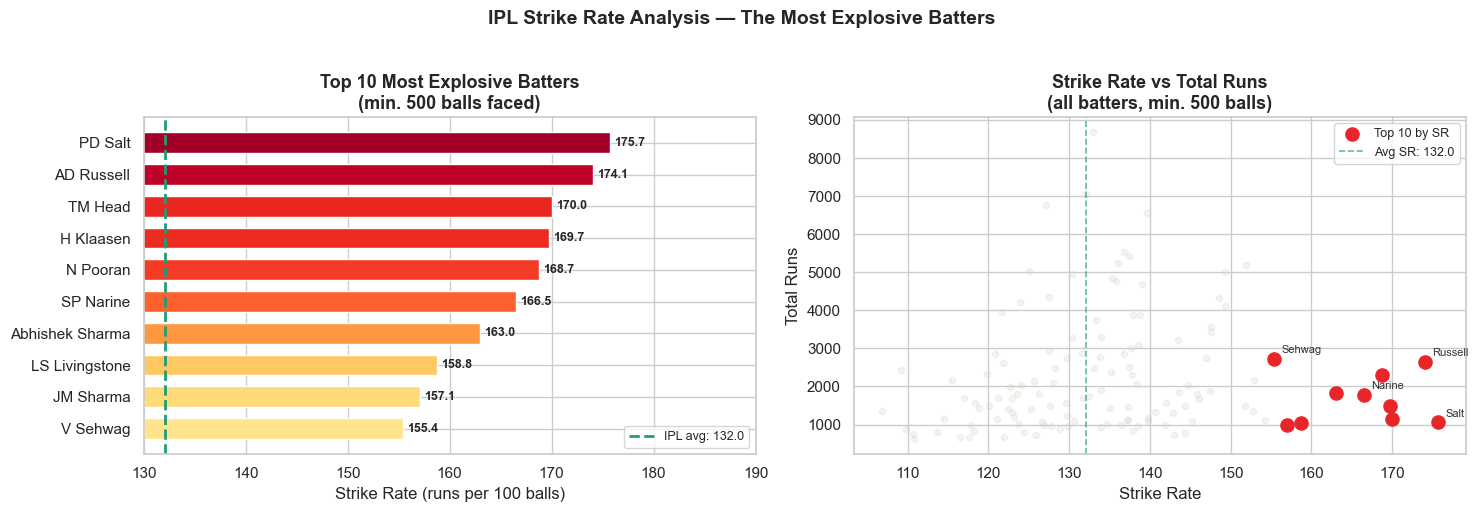

Top 10 by Strike Rate (min. 500 balls):
         batter  runs  balls  innings  strike_rate
        PD Salt  1056    601       34       175.71
     AD Russell  2655   1525      114       174.10
        TM Head  1146    674       37       170.03
      H Klaasen  1480    872       45       169.72
       N Pooran  2293   1359       86       168.73
      SP Narine  1780   1069      118       166.51
Abhishek Sharma  1816   1114       74       163.02
 LS Livingstone  1051    662       47       158.76
      JM Sharma   991    631       47       157.05
       V Sehwag  2728   1755      104       155.44

IPL overall average strike rate: 132.0
Top 10 average strike rate:      165.9 — 33.9 above IPL average


In [12]:
batters_all = df.groupby('batter').agg(
    runs    = ('runs_batter', 'sum'),
    balls   = ('balls_faced', 'sum'),
    innings = ('match_id',    'nunique')
).reset_index()
batters_all['strike_rate'] = (batters_all['runs'] / batters_all['balls'] * 100).round(2)

# Qualified: minimum 500 balls faced
top_sr = batters_all[batters_all['balls'] >= 500].nlargest(10, 'strike_rate').reset_index(drop=True)
ipl_avg_sr = df['runs_batter'].sum() / df['balls_faced'].sum() * 100

# Colour gradient — deeper red = higher SR
import matplotlib.colors as mcolors
norm   = mcolors.Normalize(vmin=top_sr['strike_rate'].min() - 5, vmax=top_sr['strike_rate'].max() + 2)
cmap   = plt.cm.YlOrRd
colors = [cmap(norm(sr)) for sr in top_sr['strike_rate'][::-1]]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: Strike Rate bar chart ───────────────────────────────────────────────
bars = axes[0].barh(top_sr['batter'][::-1], top_sr['strike_rate'][::-1],
                    color=colors, height=0.65)
axes[0].axvline(ipl_avg_sr, color='#1D9E75', linestyle='--', linewidth=2,
                label=f'IPL avg: {ipl_avg_sr:.1f}')
axes[0].set_title('Top 10 Most Explosive Batters\n(min. 500 balls faced)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Strike Rate (runs per 100 balls)')
axes[0].set_xlim(130, 190)
axes[0].legend(fontsize=9)

for bar, val in zip(bars, top_sr['strike_rate'][::-1]):
    axes[0].text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}', va='center', fontweight='bold', fontsize=9)

# ── Right: Runs vs Strike Rate scatter — positions in 2D space ───────────────
scatter_pool = batters_all[batters_all['balls'] >= 500].copy()
axes[1].scatter(scatter_pool['strike_rate'], scatter_pool['runs'],
                alpha=0.25, s=20, color='#D3D1C7', zorder=1)

# Highlight top 10 SR players
axes[1].scatter(top_sr['strike_rate'], top_sr['runs'],
                color='#E8262A', s=90, zorder=5, label='Top 10 by SR')

# Label a few standouts
standouts = ['AD Russell', 'PD Salt', 'SP Narine', 'V Sehwag', 'GJ Maxwell']
for _, row in top_sr[top_sr['batter'].isin(standouts)].iterrows():
    axes[1].annotate(row['batter'].split()[-1],
                     (row['strike_rate'], row['runs']),
                     textcoords='offset points', xytext=(5, 4),
                     fontsize=8, color='#333')

# Reference lines
axes[1].axvline(ipl_avg_sr, color='#1D9E75', linestyle='--', linewidth=1.2,
                label=f'Avg SR: {ipl_avg_sr:.1f}', alpha=0.7)

axes[1].set_title('Strike Rate vs Total Runs\n(all batters, min. 500 balls)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Strike Rate')
axes[1].set_ylabel('Total Runs')
axes[1].legend(fontsize=9)

plt.suptitle('IPL Strike Rate Analysis — The Most Explosive Batters', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart10_strike_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 by Strike Rate (min. 500 balls):")
print(top_sr[['batter','runs','balls','innings','strike_rate']].to_string(index=False))
print(f"\nIPL overall average strike rate: {ipl_avg_sr:.1f}")
print(f"Top 10 average strike rate:      {top_sr['strike_rate'].mean():.1f} — {top_sr['strike_rate'].mean()-ipl_avg_sr:.1f} above IPL average")

### 🔍 Insight — Strike Rate Analysis

- The **IPL average strike rate is 132.0** — meaning every batter in the top 10 scores at least **23 runs per 100 balls faster** than the average player.
- **Phil Salt (175.7)** leads the list — every 100 balls he faces, he scores 44 more runs than the average IPL batter. That's the equivalent of an entire extra over of scoring.
- **Andre Russell (174.1)** is the most remarkable profile: 2,655 runs at a strike rate that places him second all-time. He is arguably the most destructive finisher in IPL history.
- **Sunil Narine (166.5)** appears in *both* the top death-over bowlers (Analysis 3) and the top strike-rate batters — a genuinely rare two-way elite player.
- The scatter plot (right) shows that most high-SR batters have moderate run totals — they play fewer balls but score fast. The ideal batter (top-right cluster) combines both: **AB de Villiers, CH Gayle, DA Warner** all sit in that premium zone.
- **Takeaway:** Strike rate is the defining batting metric in T20. Teams now build entire middle orders around batters with SRs above 150 — this data shows exactly who those players are and why they command massive IPL auction prices.

---
# 🏆 Final Conclusion — What the Data Tells Us About IPL

This project analysed **18 IPL seasons, 1,169 matches, and 280,000+ ball-by-ball deliveries** to surface patterns that aren't visible from watching matches alone.

---

### 📊 Key Findings at a Glance

| # | Analysis | The Number That Matters |
|---|----------|------------------------|
| 1 | Toss Impact | Fielding first wins 53.4% vs 45.2% for batting — an 8.2pp edge that compounds over a season |
| 2 | Team Wins | MI (151), CSK (142), KKR (135), RCB (132) — top 4 separated by just 19 wins over 18 years |
| 3 | Death Bowlers | Avg economy: 9.9 runs/over; Narine (7.50) saves ~2 runs/over — worth ~10 extra runs per match |
| 4 | Top Batters | Kohli: 8,671 runs, SR 132.9 (anchor) vs AB de Villiers: SR 151.9 (finisher) — different roles, equal value |
| 5 | Season Trends | No team has won back-to-back titles more than twice — IPL parity is real and structural |
| 6 | RCB Journey | 73.3% win rate in 2025 — their best-ever season — finally paired with their first title |
| 7 | RCB vs Big 3 | In 2025: RCB 11 wins > MI 9 > KKR 5 > CSK 4 — a generational performance |
| 8 | Fanbase | 45.5M combined followers — built through 17 years of loyalty *before* winning anything |
| 9 | Venue | Sawai Mansingh (67.9% chase rate) vs Chepauk (28.6%) — venue should change your toss decision |
| 10 | Strike Rate | IPL avg SR: 132.0; top explosive batters average 165.9 — 34 runs per 100 balls above the field |

---

### 💡 The Bigger Picture

Cricket looks like chaos from the stands. But the data reveals clear, repeatable patterns:

- **Toss strategy** is not random — fielding first has a consistent, measurable edge
- **Death overs** decide close matches — a bowler who saves 2 runs/over across 4 overs can flip a result
- **Strike rate, not just runs**, determines a batter's true match-winning value
- **Venue intelligence** is an underused edge — some grounds are structurally biased towards chasing

> *"Data doesn't replace the instinct of a great captain — it sharpens it."*

---

### 🛠️ Skills Demonstrated in This Project

| Skill | Applied In |
|-------|-----------|
| Data cleaning & deduplication | Cell 2 — match-level DataFrame construction |
| GroupBy aggregation at scale | Analyses 3, 4, 10 — bowler and batter stats |
| Cross-filtering & boolean indexing | Analyses 1, 6, 7 — toss and RCB segmentation |
| Feature engineering | Economy rate, strike rate, win % calculations |
| Multi-chart layouts | Analyses 1, 4, 10 — side-by-side subplots |
| Comparative visualisation | Analyses 7, 10 — scatter + bar combination |
| Data storytelling | Every section — specific numbers, not vague claims |

---
*Project by Hemalatha · MCA Final Year · CMR Institute of Technology, Bengaluru*  
*Dataset: IPL ball-by-ball data 2008–2025 · Tools: Python, Pandas, Matplotlib, Seaborn*

In [13]:
import pandas as pd
 
# ── Load the raw data ──────────────────────────────────────────────
df = pd.read_csv('IPL.csv', low_memory=False)
 
# Match-level table (one row per match, not per ball)
matches = df.drop_duplicates(subset='match_id')[[
    'match_id', 'toss_winner', 'toss_decision',
    'match_won_by', 'venue', 'city', 'season', 'year',
    'batting_team', 'bowling_team'
]].copy()
 

In [14]:
# ── FILE 1: pbi_matches.csv ────────────────────────────────────────
# Every match with toss info, winner, venue, year
# Used for: toss analysis, season filter slicer
 
matches.to_csv('pbi_matches.csv', index=False)
print("File 1 done — pbi_matches.csv")

File 1 done — pbi_matches.csv


In [15]:
# ── FILE 2: pbi_team_wins.csv ──────────────────────────────────────
# Total wins, matches played, win % for every team
# Used for: team wins bar chart, win % comparison
 
wins = matches['match_won_by'].value_counts().reset_index()
wins.columns = ['team', 'wins']
 
played = pd.concat([
    matches[['batting_team']].rename(columns={'batting_team': 'team'}),
    matches[['bowling_team']].rename(columns={'bowling_team': 'team'})
]).value_counts().reset_index()
played.columns = ['team', 'played']
 
team_wins = wins.merge(played, on='team')
team_wins['win_pct'] = (team_wins['wins'] / team_wins['played'] * 100).round(1)
team_wins = team_wins.sort_values('wins', ascending=False)
 
team_wins.to_csv('pbi_team_wins.csv', index=False)
print("File 2 done — pbi_team_wins.csv")
 

File 2 done — pbi_team_wins.csv


In [16]:
# ── FILE 3: pbi_batters.csv ────────────────────────────────────────
# Runs, balls, innings, strike rate per batter
# Used for: top scorers chart, strike rate scatter
 
batters = df.groupby('batter').agg(
    runs    = ('runs_batter', 'sum'),
    balls   = ('balls_faced', 'sum'),
    innings = ('match_id',    'nunique')
).reset_index()
 
batters['strike_rate'] = (batters['runs'] / batters['balls'] * 100).round(1)
 
# Only keep batters with 30+ innings (removes one-match wonders)
batters = batters[batters['innings'] >= 30]
 
batters.to_csv('pbi_batters.csv', index=False)
print("File 3 done — pbi_batters.csv")

File 3 done — pbi_batters.csv


In [17]:
# ── FILE 4: pbi_bowlers.csv ────────────────────────────────────────
# Runs, wickets, economy for every bowler
# Used for: top wicket takers, economy rate chart
 
bowlers = df.groupby('bowler').agg(
    runs    = ('runs_total',    'sum'),
    balls   = ('valid_ball',    'sum'),
    wickets = ('bowler_wicket', 'sum')
).reset_index()
 
bowlers['overs']   = (bowlers['balls'] / 6).round(1)
bowlers['economy'] = (bowlers['runs']  / bowlers['overs']).round(2)
 
# Only keep bowlers with 20+ overs (removes occasional bowlers)
bowlers = bowlers[bowlers['overs'] >= 20]
 
bowlers.to_csv('pbi_bowlers.csv', index=False)
print("File 4 done — pbi_bowlers.csv")
 

File 4 done — pbi_bowlers.csv


In [18]:
# ── FILE 5: pbi_rcb.csv ────────────────────────────────────────────
# RCB wins, losses, win % for each season year by year
# Used for: RCB journey line chart on the special page
 
rcb_names = ['Royal Challengers Bangalore', 'Royal Challengers Bengaluru']
 
rows = []
for yr in sorted(matches['year'].unique()):
    year_data = matches[matches['year'] == yr]
    rcb_matches = year_data[
        year_data['batting_team'].isin(rcb_names) |
        year_data['bowling_team'].isin(rcb_names)
    ]
    rcb_wins = year_data['match_won_by'].isin(rcb_names).sum()
    if len(rcb_matches) > 0:
        rows.append({
            'year':    yr,
            'played':  len(rcb_matches),
            'wins':    int(rcb_wins),
            'losses':  len(rcb_matches) - int(rcb_wins),
            'win_pct': round(rcb_wins / len(rcb_matches) * 100, 1)
        })
 
pd.DataFrame(rows).to_csv('pbi_rcb.csv', index=False)
print("File 5 done — pbi_rcb.csv")
 
 
# ── FINAL CHECK ────────────────────────────────────────────────────
print("\nAll 5 files created successfully!")
print("Look for them in the same folder as your IPL.csv file.")
print("\nQuick check:")
print(f"  Matches:  {len(matches)} rows")
print(f"  Teams:    {len(team_wins)} teams")
print(f"  Batters:  {len(batters)} qualified batters")
print(f"  Bowlers:  {len(bowlers)} qualified bowlers")
print(f"  RCB:      {len(rows)} seasons")
 

File 5 done — pbi_rcb.csv

All 5 files created successfully!
Look for them in the same folder as your IPL.csv file.

Quick check:
  Matches:  1169 rows
  Teams:    19 teams
  Batters:  159 qualified batters
  Bowlers:  332 qualified bowlers
  RCB:      18 seasons
